In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [47]:
class LogisticModel:
    def __init__(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.model = LogisticRegression(max_iter=1000)

    def train(self):
        self.model.fit(self.X_train, self.y_train)

    def predict(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        matrix = confusion_matrix(y_test, y_pred)
        recall = matrix[1][1] / (matrix[1][1] + matrix[1][0])
        return y_pred ,acc , prec, recall, matrix

    def save_model(self, file_path):
        joblib.dump(self.model, file_path)

In [48]:
# Load data
df = pd.read_csv('../data/clean_diabetes.csv') 

# Split Features and Target
X = df.drop('class', axis=1)
y = df['class']

# Split Data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: View the first few rows to verify
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


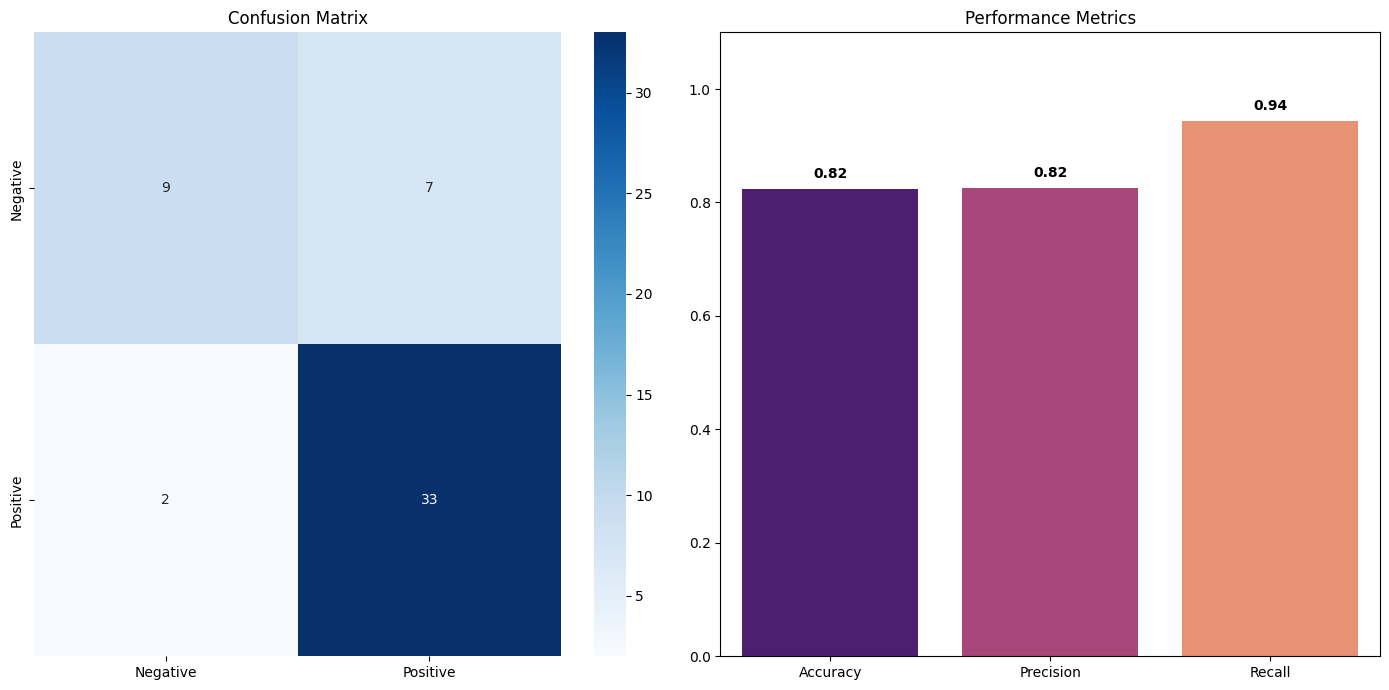

In [57]:
# Train and Evaluate
l1 = LogisticModel(X_train, y_train)
l1.train()
predictions = l1.predict(X_test, y_test)

# Save results
l1.save_model('../models/logistic_model.joblib')

y_pred, acc, prec, recall, matrix = l1.predict(X_test, y_test)

# 2. Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Heatmap
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
ax1.set_title('Confusion Matrix')

# Bar Chart
metrics_list = ['Accuracy', 'Precision', 'Recall']
values_list = [acc, prec, recall]
sns.barplot(x=metrics_list, y=values_list, hue=metrics_list, palette='magma', ax=ax2, legend=False)
ax2.set_title('Performance Metrics')
ax2.set_ylim(0, 1.1) 

for i, v in enumerate(values_list):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

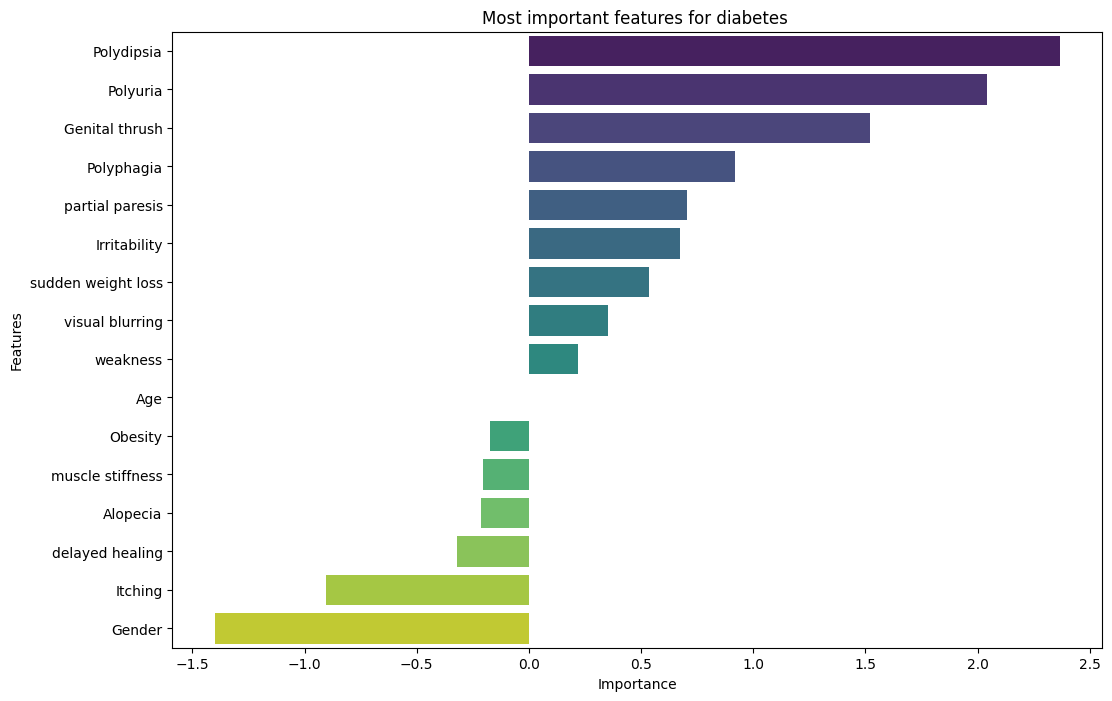

In [56]:
importance = l1.model.coef_[0]
feature_names = X.columns


feature_importance = pd.DataFrame({'Features': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Features', data=feature_importance, hue='Features', palette='viridis', legend=False)
plt.title('Most important features for diabetes ')
plt.show()